In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

%matplotlib inline

In [2]:
df = pd.read_csv(
    r"C:\Users\rites\Downloads\automobile_dataset.csv",
    engine="python",
     
)

In [3]:
df.head()

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
0,Mercedes-Benz,GLE,2024,Petrol,Automatic,2.3,100,186.0,196.0,1,0.0,NaN,Silver,SUV,AWD,30.0,IL,64140
1,Hyundai,Tucson,2008,Petrol,Automatic,2.3,387035,189.0,190.0,4,0.0,NaN,Blue,SUV,FWD,35.0,FL,500
2,Volkswagen,Golf,2021,Hybrid,NaN,1.9,46054,158.0,153.0,1,0.0,Partial Service,Gray,Hatchback,AWD,43.0,NY,16429
3,Chevrolet,Tahoe,2005,Petrol,NaN,2.2,141302,169.0,165.0,5,1.0,No Service,Blue,SUV,AWD,NaN,FL,2199
4,Toyota,Camry,2022,Petrol,Automatic,1.9,32813,149.0,141.0,1,0.0,Full Service,Brown,Sedan,FWD,38.0,CA,21792


In [4]:
df.tail()

,Make,Model,Year,Fuel_Type,Transmission,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Service_History,Color,Body_Type,Drivetrain,Fuel_Efficiency,Location,Selling_Price
5495,Volkswagen,Tiguan,2022,Petrol,Automatic,NaN,29506,161.0,NaN,1,0.0,Partial Service,Black,SUV,AWD,33.0,GA,20333
5496,Nissan,Pathfinder,2006,Petrol,Automatic,3.1,287332,243.0,227.0,5,1.0,No Service,Gray,SUV,AWD,NaN,NY,500
5497,BMW,X3,2013,Petrol,Automatic,2.2,95961,171.0,152.0,2,1.0,No Service,Blue,SUV,AWD,32.0,MI,9882
5498,Volkswagen,Golf,2020,Hybrid,Automatic,1.5,56643,135.0,125.0,2,1.0,No Service,White,Hatchback,FWD,57.0,NY,10474
5499,Chevrolet,Tahoe,2011,Petrol,Automatic,2.1,169929,168.0,158.0,3,1.0,NaN,Gray,SUV,AWD,NaN,MI,6193


In [5]:
df.shape

(5500, 18)

In [6]:
print(df.columns.tolist())

['Make', 'Model', 'Year', 'Fuel_Type', 'Transmission', 'Engine_Size', 'Mileage', 'Horsepower', 'Torque', 'Owners', 'Accident_History', 'Service_History', 'Color', 'Body_Type', 'Drivetrain', 'Fuel_Efficiency', 'Location', 'Selling_Price']


In [7]:
df.columns

Index(['Make', 'Model', 'Year', 'Fuel_Type', 'Transmission', 'Engine_Size',
       'Mileage', 'Horsepower', 'Torque', 'Owners', 'Accident_History',
       'Service_History', 'Color', 'Body_Type', 'Drivetrain',
       'Fuel_Efficiency', 'Location', 'Selling_Price'],
      dtype='str')

In [8]:
df.dtypes

Make                    str
Model                   str
Year                  int64
Fuel_Type               str
Transmission            str
Engine_Size         float64
Mileage               int64
Horsepower          float64
Torque              float64
Owners                int64
Accident_History    float64
Service_History         str
Color                   str
Body_Type               str
Drivetrain              str
Fuel_Efficiency     float64
Location                str
Selling_Price         int64
dtype: object

In [9]:
df.describe()

,Year,Engine_Size,Mileage,Horsepower,Torque,Owners,Accident_History,Fuel_Efficiency,Selling_Price
count,5500.000000,4656.000000,5500.000000,4700.000000,4701.000000,5500.000000,4688.000000,4706.000000,5500.000000
mean,2014.494000,2.450623,114529.481636,198.236596,189.014678,2.464000,0.408063,34.179771,12319.873636
std,5.789745,0.843913,91858.943421,55.678165,56.631309,1.280022,0.491527,15.085473,12658.478862
min,2005.000000,0.000000,100.000000,97.000000,77.000000,1.000000,0.000000,10.000000,500.000000
25%,2009.000000,2.000000,39112.000000,160.000000,151.000000,1.000000,0.000000,27.000000,1304.750000
50%,2014.000000,2.400000,96926.500000,187.000000,178.000000,2.000000,0.000000,32.000000,8586.000000
75%,2020.000000,3.000000,172757.500000,231.000000,219.000000,3.000000,1.000000,37.000000,19097.500000
max,2024.000000,5.700000,536731.000000,434.000000,443.000000,5.000000,1.000000,141.000000,86692.000000


In [10]:
df.isnull().sum()

Make                  0
Model                 0
Year                  0
Fuel_Type             0
Transmission        827
Engine_Size         844
Mileage               0
Horsepower          800
Torque              799
Owners                0
Accident_History    812
Service_History     855
Color               803
Body_Type             0
Drivetrain            0
Fuel_Efficiency     794
Location            782
Selling_Price         0
dtype: int64

In [11]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum() / len(df)) * 100, 2)
})

missing = missing[missing["Missing Values"] > 0]
missing.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
Service_History,855,15.55
Engine_Size,844,15.35
Transmission,827,15.04
Accident_History,812,14.76
Color,803,14.60
Horsepower,800,14.55
Torque,799,14.53
Fuel_Efficiency,794,14.44
Location,782,14.22


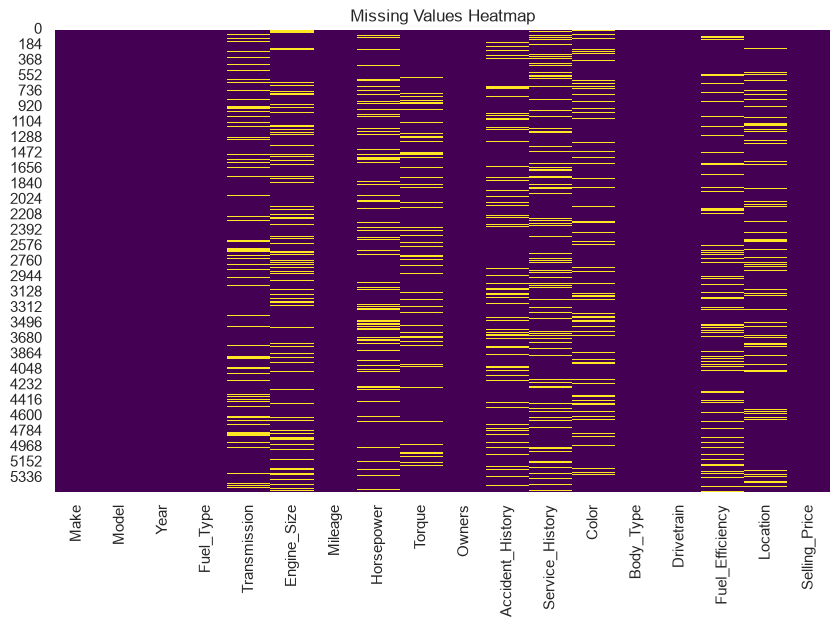

In [12]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title("Missing Values Heatmap")
plt.show()

In [13]:
num_cols = ['Engine_Size', 'Horsepower', 'Torque', 'Fuel_Efficiency']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [14]:
cat_cols = [
    'Transmission',
    'Accident_History',
    'Service_History',
    'Color',
    'Location'
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [15]:
df.isnull().sum()

Make                0
Model               0
Year                0
Fuel_Type           0
Transmission        0
Engine_Size         0
Mileage             0
Horsepower          0
Torque              0
Owners              0
Accident_History    0
Service_History     0
Color               0
Body_Type           0
Drivetrain          0
Fuel_Efficiency     0
Location            0
Selling_Price       0
dtype: int64

# 🧹 Data Cleaning and Missing Value Treatment

## Objective
Before performing Exploratory Data Analysis (EDA), it is essential to identify and handle missing values to ensure the dataset is accurate, consistent, and suitable for analysis.

## Missing Value Analysis
The dataset contained missing values in the following columns:

| Column | Missing Values |
|---------|---------------:|
| Transmission | 827 |
| Engine_Size | 844 |
| Horsepower | 800 |
| Torque | 799 |
| Accident_History | 812 |
| Service_History | 855 |
| Color | 803 |
| Fuel_Efficiency | 794 |
| Location | 782 |

## Missing Value Handling Strategy

### Numerical Features
The following numerical columns contained missing values:

- Engine_Size
- Horsepower
- Torque
- Fuel_Efficiency

These missing values were replaced using the **median** of each column because the median is less sensitive to extreme values (outliers) and provides a robust estimate of the central tendency.

### Categorical Features
The following categorical columns contained missing values:

- Transmission
- Accident_History
- Service_History
- Color
- Location

These missing values were replaced using the **mode** (most frequently occurring value) to preserve the most common category without introducing unrealistic values.

## Why This Approach?

- ✔ Prevents unnecessary loss of valuable data.
- ✔ Maintains the original dataset size.
- ✔ Reduces the impact of outliers on numerical features.
- ✔ Preserves the distribution of categorical variables.
- ✔ Ensures the dataset is clean and ready for further analysis and visualization.

**Result:** After applying the above preprocessing techniques, all missing values were successfully handled, making the dataset suitable for Exploratory Data Analysis (EDA).

In [16]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [17]:
print("Duplicate Columns:", df.T.duplicated().sum())

Duplicate Columns: 0


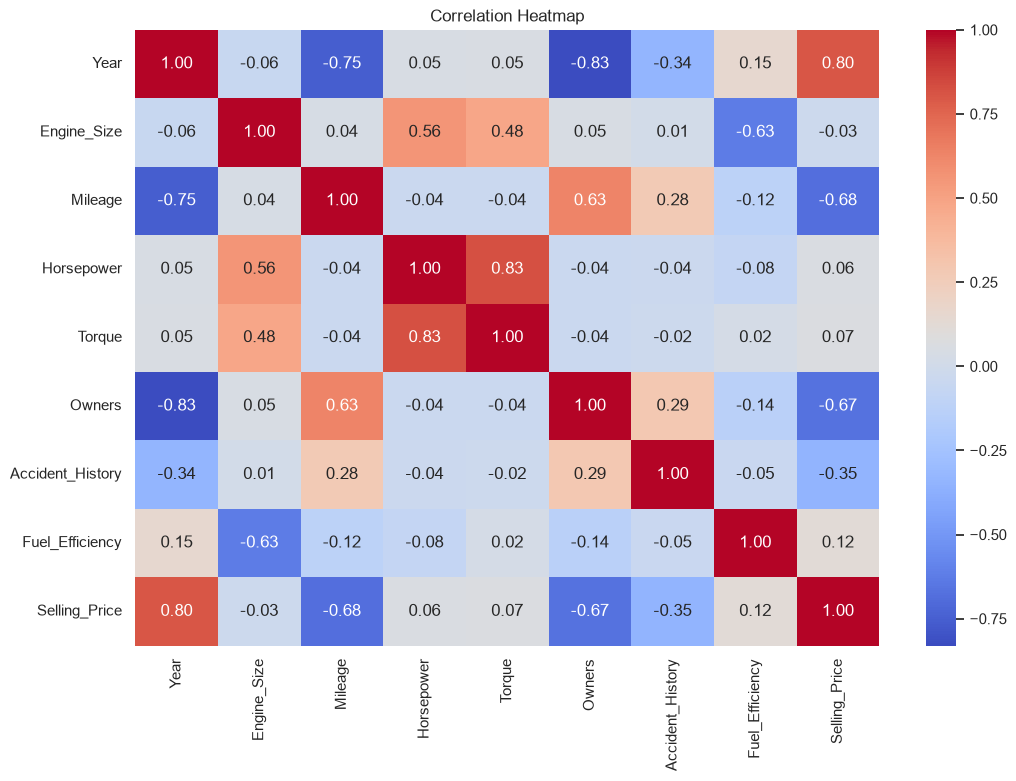

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

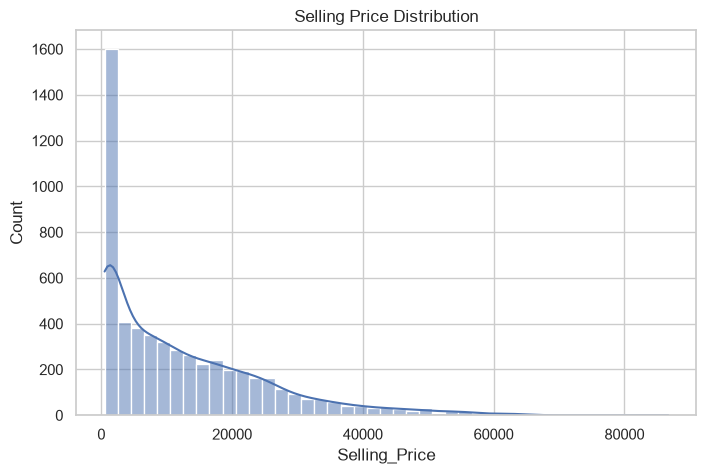

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Selling_Price'], kde=True)
plt.title("Selling Price Distribution")
plt.show()

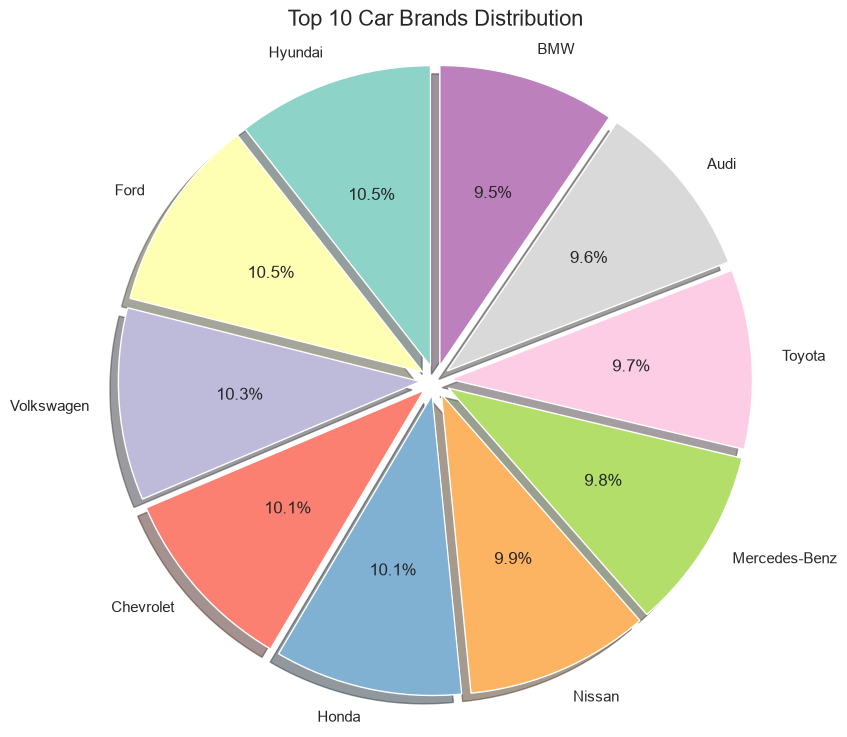

In [20]:
top_brands = df['Make'].value_counts().head(10)

colors = plt.cm.Set3.colors

plt.figure(figsize=(9, 9))
plt.pie(
    top_brands,
    labels=top_brands.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    shadow=True,
    explode=[0.05]*10
)

plt.title("Top 10 Car Brands Distribution", fontsize=16)
plt.axis('equal')
plt.show()

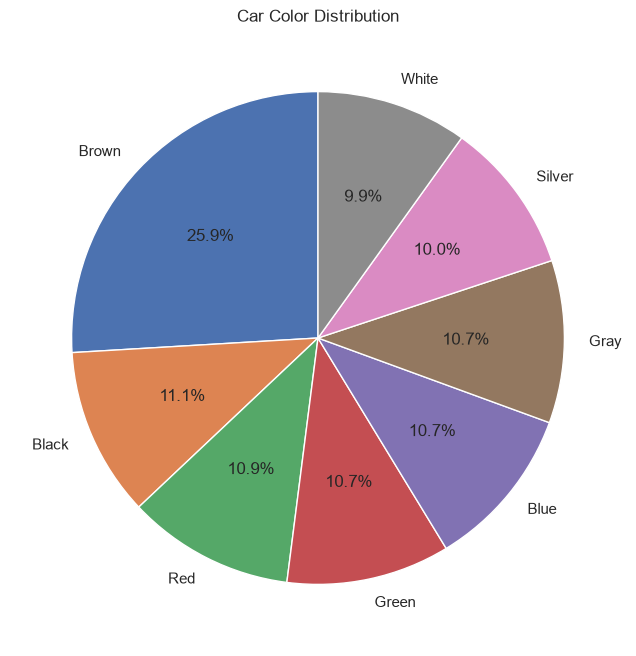

In [21]:
plt.figure(figsize=(8,8))

df['Color'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Car Color Distribution")
plt.ylabel("")
plt.show()

In [22]:
color_data = df['Color'].value_counts().reset_index()
color_data.columns = ['Color', 'Count']

color_data['Percentage'] = (
    color_data['Count'] / color_data['Count'].sum() * 100
).round(2)

color_data

,Color,Count,Percentage
0,Brown,1427,25.95
1,Black,610,11.09
2,Red,602,10.95
3,Green,590,10.73
4,Blue,589,10.71
5,Gray,587,10.67
6,Silver,550,10.00
7,White,545,9.91


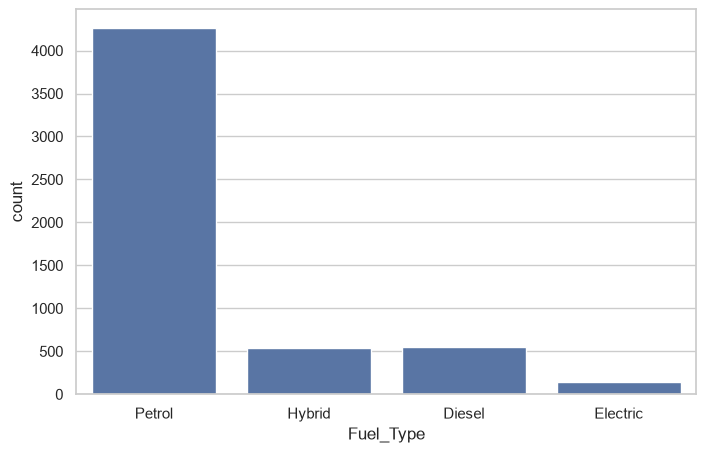

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(x='Fuel_Type', data=df)
plt.show()

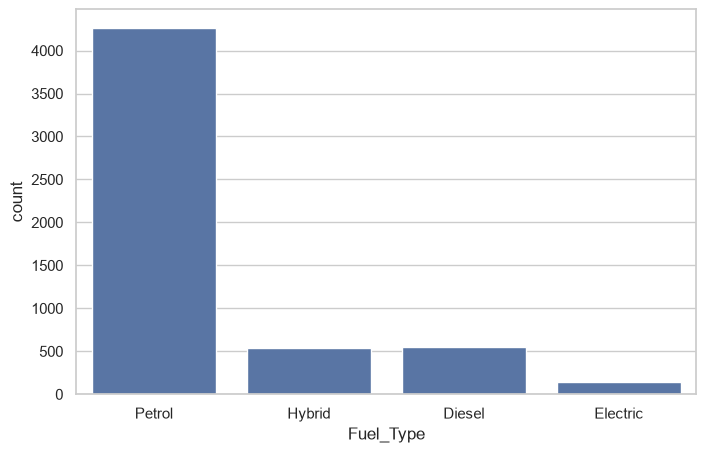

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x='Fuel_Type', data=df)
plt.show()

C:\Users\rites\AppData\Local\Temp\ipykernel_19612\1751666033.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Transmission', data=df, palette='Set2')


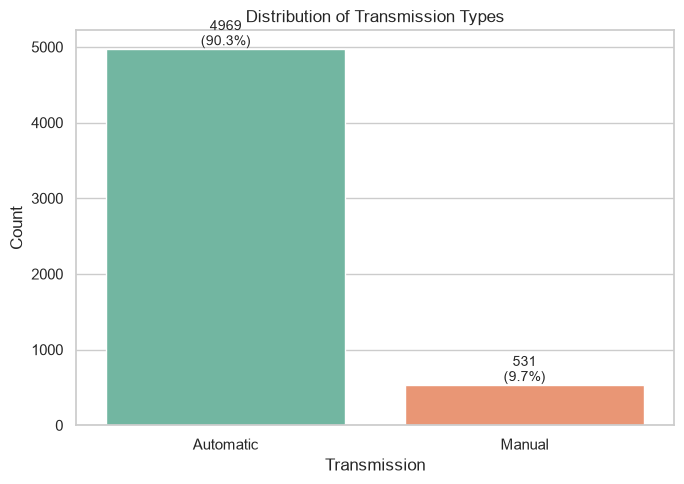

In [25]:
plt.figure(figsize=(7,5))

ax = sns.countplot(x='Transmission', data=df, palette='Set2')

# Total number of observations
total = len(df)

# Add count and percentage on each bar
for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(f'{count}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center',
                va='bottom',
                fontsize=10)

plt.title("Distribution of Transmission Types")
plt.xlabel("Transmission")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

C:\Users\rites\AppData\Local\Temp\ipykernel_19612\3320631654.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Accident_History', data=df, palette='Set2')


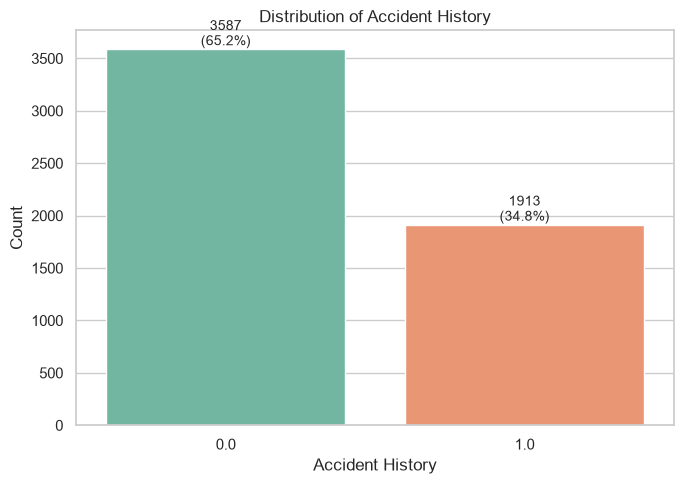

In [26]:
plt.figure(figsize=(7,5))

ax = sns.countplot(x='Accident_History', data=df, palette='Set2')

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(f'{count}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center',
                va='bottom',
                fontsize=10)

plt.title("Distribution of Accident History")
plt.xlabel("Accident History")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

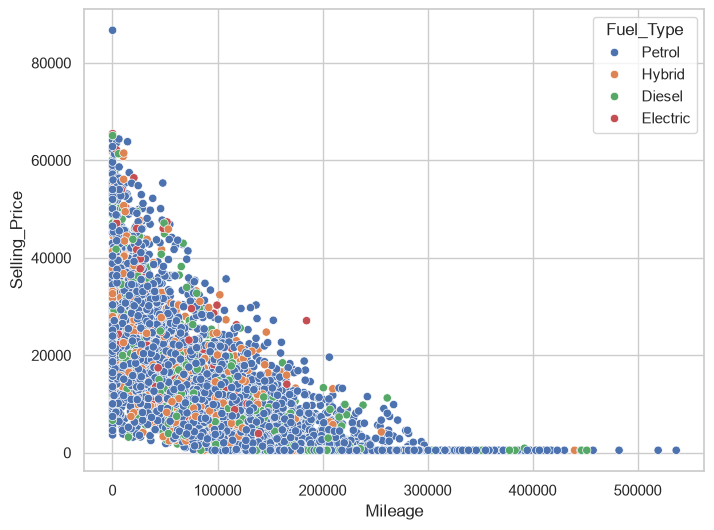

In [27]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Mileage',
                y='Selling_Price',
                hue='Fuel_Type',
                data=df)
plt.show()

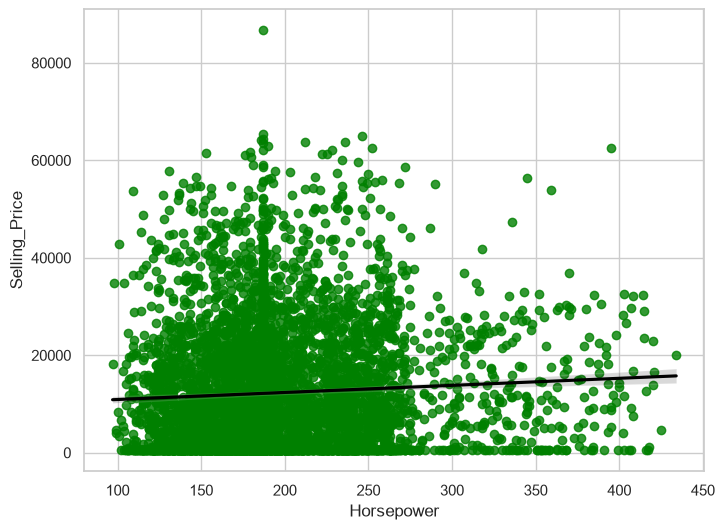

In [28]:
plt.figure(figsize=(8,6))

sns.regplot(
    x='Horsepower',
    y='Selling_Price',
    data=df,
    scatter_kws={'color': 'green'},
    line_kws={'color': 'black'}
)

plt.show()

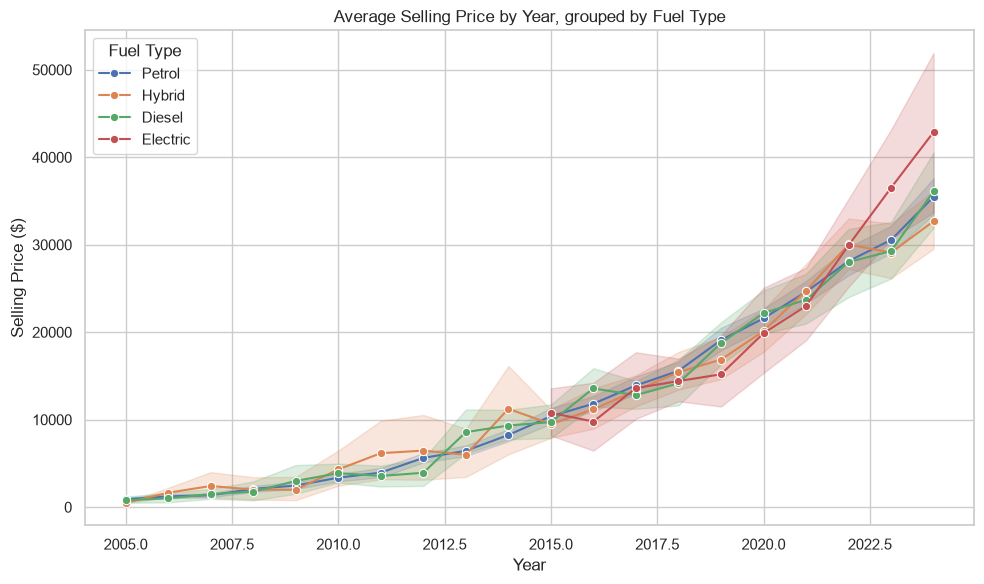

In [29]:
plt.figure(figsize=(10,6))
sns.lineplot(x='Year', y='Selling_Price', hue='Fuel_Type', data=df, marker='o')
plt.title('Average Selling Price by Year, grouped by Fuel Type')
plt.xlabel('Year')
plt.ylabel('Selling Price ($)')
plt.legend(title='Fuel Type')
plt.tight_layout()
plt.show()

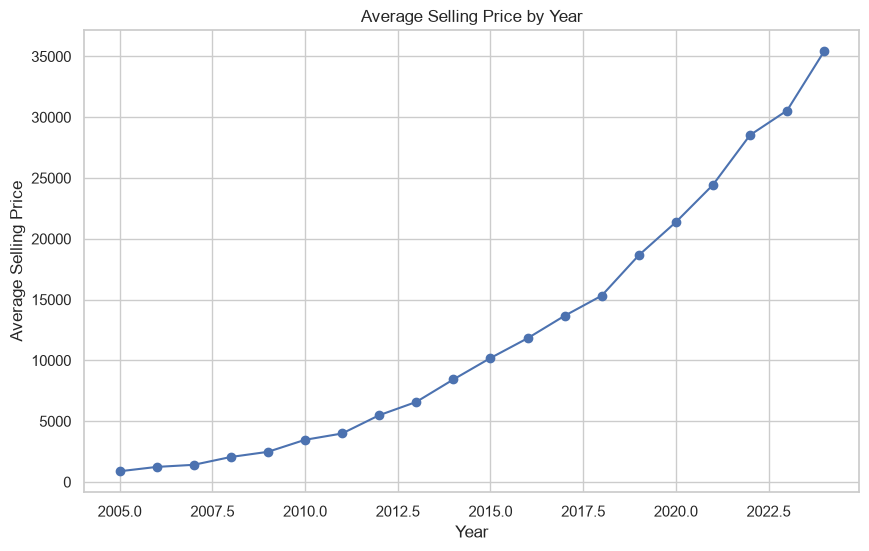

In [30]:
plt.figure(figsize=(10,6))

avg_price = df.groupby('Year')['Selling_Price'].mean()

plt.plot(avg_price.index, avg_price.values, marker='o')

plt.title("Average Selling Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Selling Price")
plt.grid(True)
plt.show()

In [31]:
df.groupby('Fuel_Type')['Selling_Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Fuel_Type,,,,,,,,
Diesel,551.0,13202.159710,12550.344531,500.0,2495.5,10194.0,20086.0,65083.0
Electric,145.0,21521.662069,13918.588237,500.0,11348.0,17866.0,27143.0,65486.0
Hybrid,537.0,16284.366853,12373.973254,500.0,6248.0,14590.0,23585.0,61686.0
Petrol,4267.0,11394.321303,12435.904252,500.0,511.5,7370.0,17602.0,86692.0


C:\Users\rites\AppData\Local\Temp\ipykernel_19612\3003578818.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


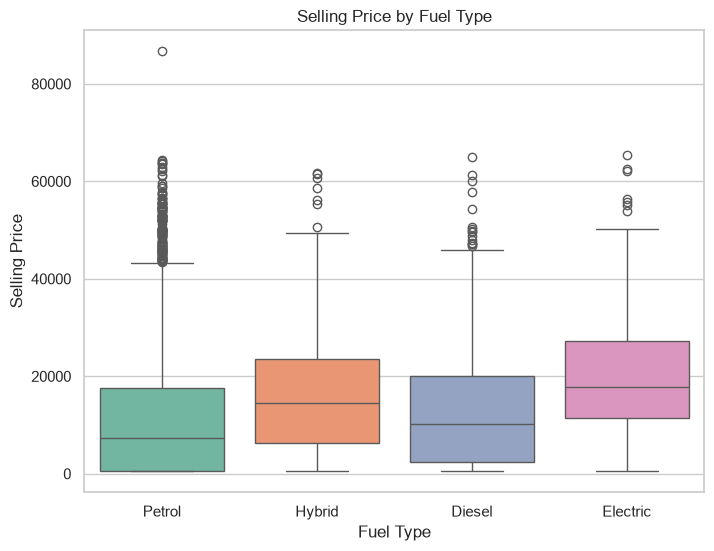

In [32]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='Fuel_Type',
    y='Selling_Price',
    data=df,
    palette='Set2'
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

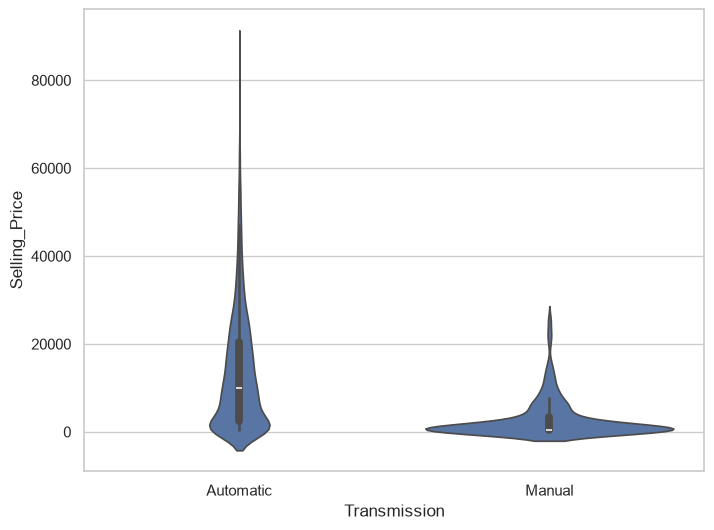

In [33]:
plt.figure(figsize=(8,6))

sns.violinplot(
    x='Transmission',
    y='Selling_Price',
    data=df
)

plt.show()

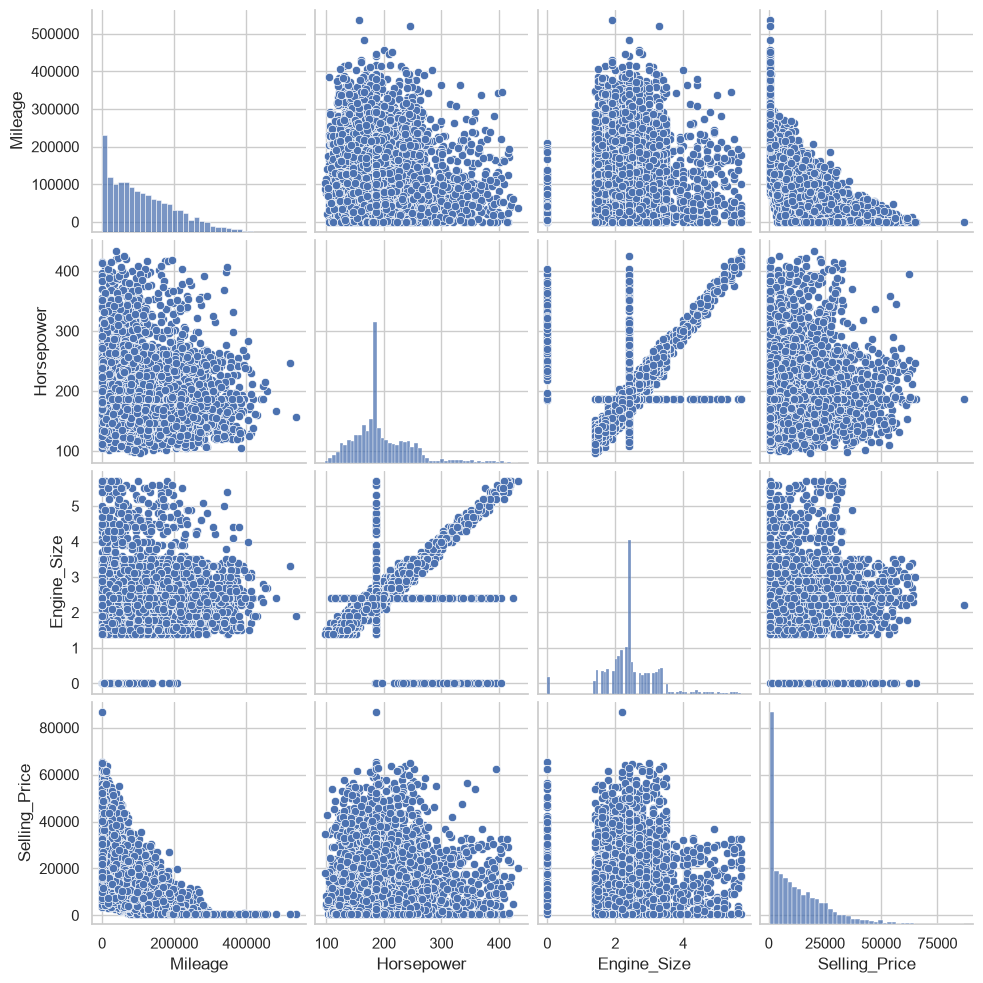

In [34]:
sns.pairplot(
    df[['Mileage',
        'Horsepower',
        'Engine_Size',
        'Selling_Price']]
)
plt.show()

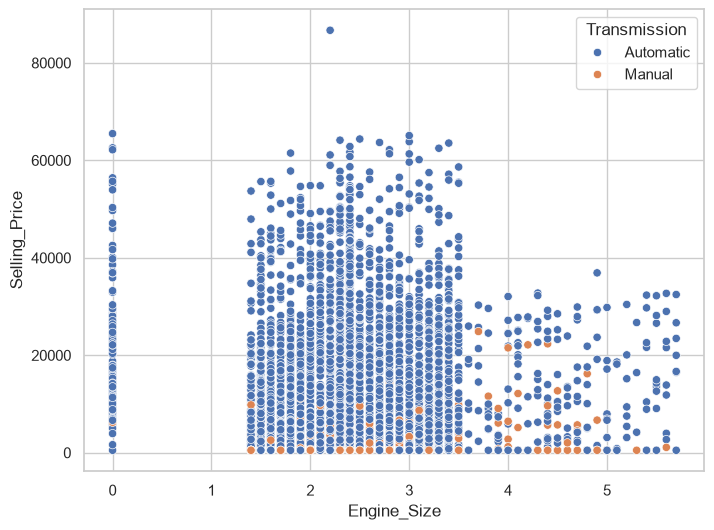

In [35]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Engine_Size',
                y='Selling_Price',
                hue='Transmission',
                data=df)
plt.show() 

In [36]:
df.groupby('Transmission')['Selling_Price'].mean().sort_values(ascending=False)

Transmission
Automatic    13327.030791
Manual        2895.082863
Name: Selling_Price, dtype: float64

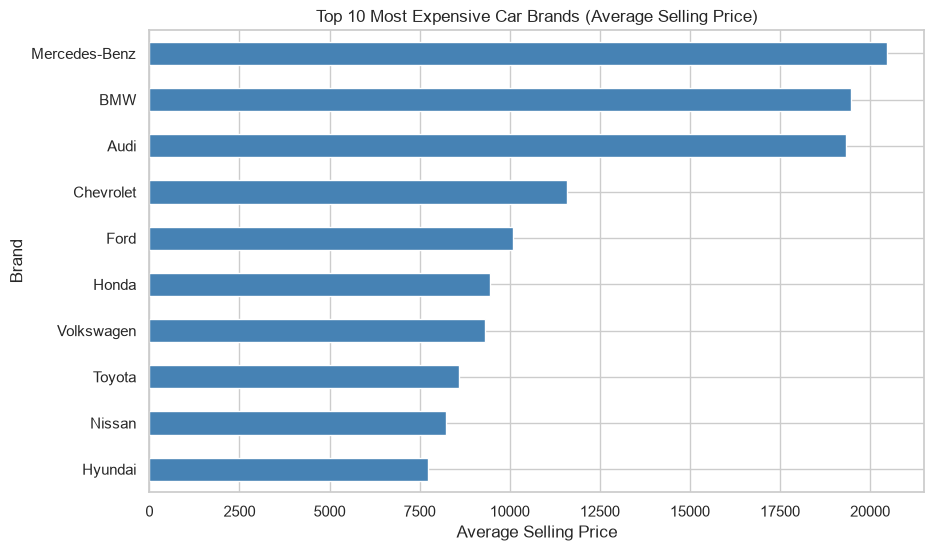

In [37]:
brand_price = df.groupby('Make')['Selling_Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
brand_price.head(10).plot(kind='barh', color='steelblue')

plt.title("Top 10 Most Expensive Car Brands (Average Selling Price)")
plt.xlabel("Average Selling Price")
plt.ylabel("Brand")
plt.gca().invert_yaxis()   # Highest price at the top
plt.show()

In [38]:
brand_price.head(10)

Make
Mercedes-Benz    20482.828096
BMW              19459.024904
Audi             19326.272727
Chevrolet        11579.742806
Ford             10084.564767
Honda             9460.481013
Volkswagen        9327.112478
Toyota            8589.265537
Nissan            8240.380074
Hyundai           7725.307427
Name: Selling_Price, dtype: float64

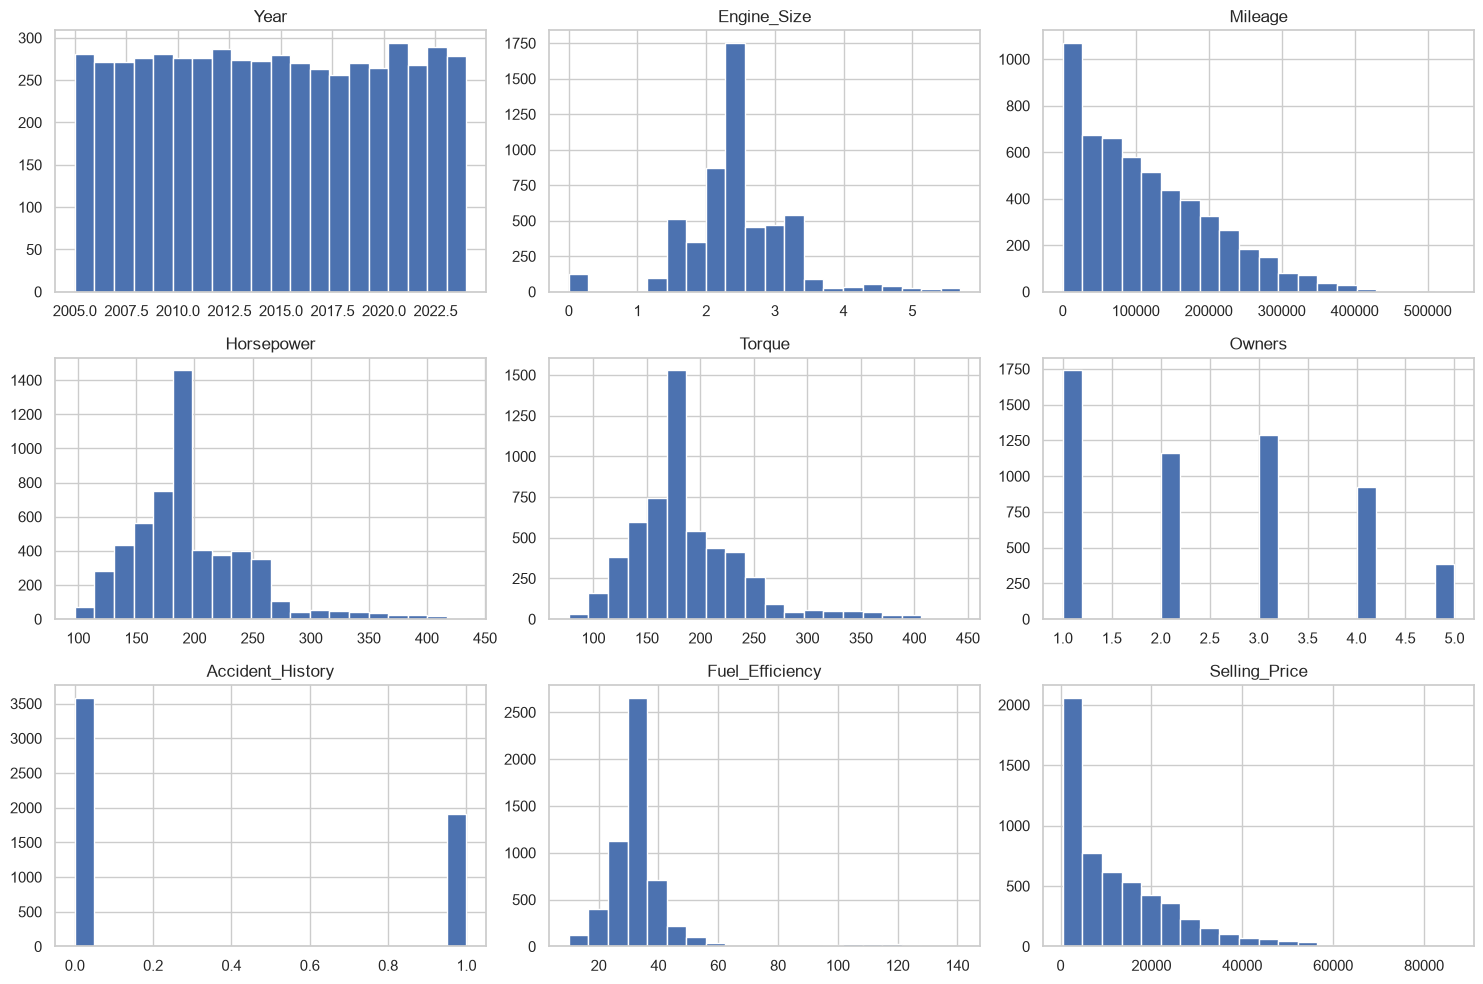

In [39]:
df.select_dtypes(include=np.number).hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

In [40]:
print("Business Insights")
print("-"*50)

print("Average Selling Price")
print(df['Selling_Price'].mean())

print()

print("Most Popular Brand")
print(df['Make'].mode()[0])

print()

print("Most Popular Fuel Type")
print(df['Fuel_Type'].mode()[0])

print()

print("Newest Vehicle")
print(df['Year'].max())

print()

print("Oldest Vehicle")
print(df['Year'].min())

Business Insights
--------------------------------------------------
Average Selling Price
12319.873636363636

Most Popular Brand
Ford

Most Popular Fuel Type
Petrol

Newest Vehicle
2024

Oldest Vehicle
2005


C:\Users\rites\AppData\Local\Temp\ipykernel_19612\3956192196.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


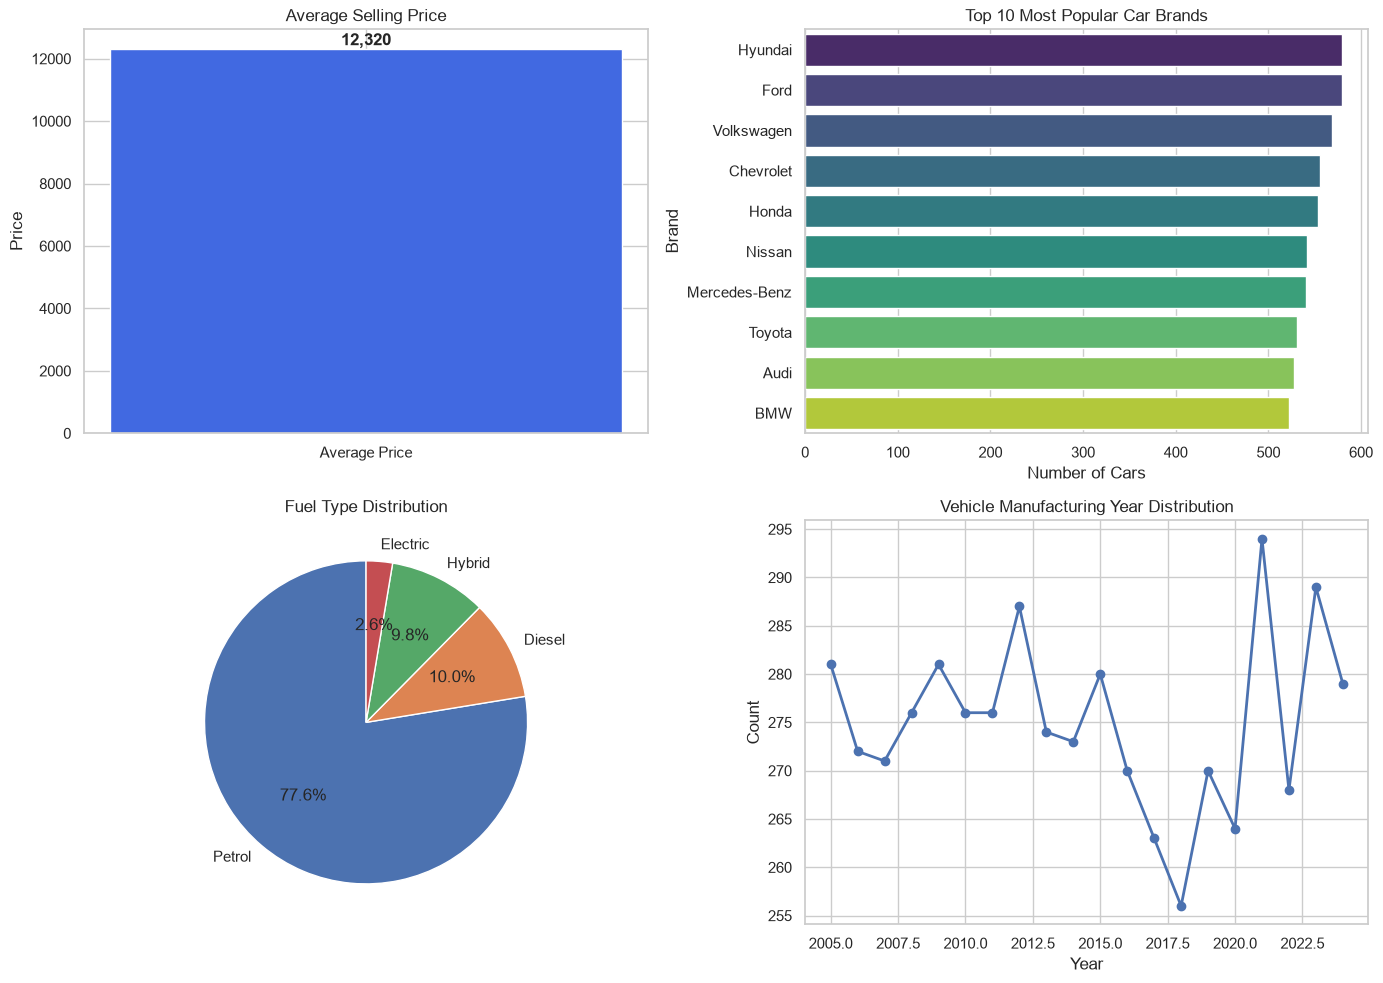

In [41]:
# ==============================
# Business Insights Dashboard
# ==============================

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Average Selling Price
avg_price = df["Selling_Price"].mean()

axes[0,0].bar(["Average Price"], [avg_price], color="royalblue")
axes[0,0].set_title("Average Selling Price")
axes[0,0].set_ylabel("Price")

# Show value on bar
axes[0,0].text(
    0,
    avg_price,
    f"{avg_price:,.0f}",
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight="bold"
)

# -------------------------------------

# 2. Most Popular Brand
brand = df["Make"].value_counts().head(10)

sns.barplot(
    x=brand.values,
    y=brand.index,
    palette="viridis",
    ax=axes[0,1]
)

axes[0,1].set_title("Top 10 Most Popular Car Brands")
axes[0,1].set_xlabel("Number of Cars")
axes[0,1].set_ylabel("Brand")

# -------------------------------------

# 3. Fuel Type Distribution
fuel = df["Fuel_Type"].value_counts()

axes[1,0].pie(
    fuel,
    labels=fuel.index,
    autopct="%1.1f%%",
    startangle=90
)

axes[1,0].set_title("Fuel Type Distribution")

# -------------------------------------

# 4. Vehicle Manufacturing Year
year = df["Year"].value_counts().sort_index()

axes[1,1].plot(
    year.index,
    year.values,
    marker="o",
    linewidth=2
)

axes[1,1].set_title("Vehicle Manufacturing Year Distribution")
axes[1,1].set_xlabel("Year")
axes[1,1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [42]:
print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print(f"Average Selling Price : {df['Selling_Price'].mean():,.2f}")

print(f"Most Popular Brand : {df['Make'].mode()[0]}")

print(f"Most Popular Fuel Type : {df['Fuel_Type'].mode()[0]}")

print(f"Newest Vehicle : {df['Year'].max()}")

print(f"Oldest Vehicle : {df['Year'].min()}")

print(f"Total Brands : {df['Make'].nunique()}")

print(f"Total Models : {df['Model'].nunique()}")

print(f"Average Mileage : {df['Mileage'].mean():,.2f}")

print(f"Average Engine Size : {df['Engine_Size'].mean():,.2f}")

print("="*60)

BUSINESS INSIGHTS
Average Selling Price : 12,319.87
Most Popular Brand : Ford
Most Popular Fuel Type : Petrol
Newest Vehicle : 2024
Oldest Vehicle : 2005
Total Brands : 10
Total Models : 40
Average Mileage : 114,529.48
Average Engine Size : 2.44


# 📌 Project Summary

## Overview

This project focused on performing **Exploratory Data Analysis (EDA)** on a used automobile dataset to understand the factors influencing vehicle prices and market trends. The analysis was carried out using **Python** with the help of **NumPy, Pandas, Matplotlib, and Seaborn**.

The dataset contains information about different used vehicles, including their manufacturer, model, year, fuel type, transmission, engine specifications, mileage, ownership history, service records, and selling price.

---

# 🛠 Data Preprocessing

Before analysis, the dataset was carefully cleaned to improve data quality.

The following preprocessing steps were performed:

- Removed duplicate records.
- Identified missing values across multiple features.
- Replaced missing numerical values using the **Median**.
- Replaced missing categorical values using the **Mode**.
- Verified that the dataset contained no missing values after preprocessing.
- Prepared the dataset for visualization and analysis.

---

# 📊 Exploratory Data Analysis (EDA)

Several visualizations were created to understand the dataset and identify important patterns.

The analysis included:

- Distribution of Selling Price
- Correlation Heatmap
- Top 10 Car Brands
- Fuel Type Distribution
- Transmission Analysis
- Vehicle Manufacturing Year Distribution
- Mileage vs Selling Price
- Engine Size vs Selling Price
- Horsepower vs Selling Price
- Outlier Detection using Boxplots
- Pairplot for Numerical Features

These visualizations helped identify relationships between different vehicle attributes and their impact on resale value.

---

# 📊 Business Insights

## Objective

The objective of this section is to extract meaningful insights from the used automobile dataset by analyzing vehicle prices, brand popularity, fuel preferences, and manufacturing trends. These insights can help dealerships, buyers, and sellers make informed decisions.

---

# 📈 Key Business Metrics

| Metric | Value |
|--------|-------|
| **Average Selling Price** | **12,319.87** |
| **Most Popular Brand** | **Ford** |
| **Most Popular Fuel Type** | **Petrol** |
| **Newest Vehicle** | **2024** |
| **Oldest Vehicle** | **2005** |
| **Total Car Brands** | **10** |
| **Total Car Models** | **40** |
| **Average Mileage** | **114,529.48 km** |
| **Average Engine Size** | **2.44 L** |

---

# 📊 Key Findings

Based on the exploratory data analysis, the following observations were made:

- 🚗 **Ford** is the most frequently listed brand, indicating its strong presence in the used car market.
- ⛽ **Petrol** vehicles dominate the dataset, making them the most common fuel type among listed cars.
- 💰 The **average selling price** of vehicles in the dataset is **12,319.87**, providing an estimate of the overall market value.
- 📅 The dataset includes vehicles manufactured between **2005** and **2024**, covering nearly two decades of automobiles.
- 🏷️ The dataset contains **10 different car brands** and **40 unique models**, offering a diverse representation of the used car market.
- 🛣️ The average vehicle mileage is **114,529.48 km**, suggesting that most listed vehicles have been driven extensively before resale.
- ⚙️ The average engine size is **2.44 liters**, indicating that medium-sized engines are the most common in this dataset.

---

# 📌 Business Recommendations

Based on the analysis, the following recommendations can be made:

- Focus inventory on popular brands such as **Ford**, as they represent a significant portion of the market.
- Since **Petrol vehicles** dominate the listings, dealerships should maintain adequate stock while also monitoring the growing demand for alternative fuel vehicles.
- Pricing strategies should consider vehicle age, mileage, engine size, and horsepower, as these attributes significantly influence resale value.
- Buyers looking for better value should compare mileage and manufacturing year alongside the selling price.
- Sellers can improve resale value by maintaining a complete service history and ensuring proper vehicle maintenance.

---

# ✅ Conclusion

The exploratory data analysis successfully identified important market trends within the used automobile dataset. The findings indicate that **brand popularity, fuel type, manufacturing year, mileage, and engine specifications** play a crucial role in determining vehicle resale prices.

This project demonstrates practical skills in **data cleaning, exploratory data analysis (EDA), statistical analysis, data visualization, and business insight generation** using **Python, NumPy, Pandas, Matplotlib, and Seaborn**. The insights obtained can support better decision-making for used car dealerships, online automobile marketplaces, buyers, and sellers.

# ✅ Skills Demonstrated

- Data Cleaning
- Handling Missing Values
- Exploratory Data Analysis (EDA)
- Data Visualization
- Feature Understanding
- Statistical Summary
- Business Insight Generation
- Analytical Thinking
- Python Programming